 # Библиотеки и настройки

In [1]:
# Библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from pathlib import Path

In [2]:
# Установка цветовой схемы 
palette = sns.color_palette('PRGn')
sns.set_theme(palette=palette, style='ticks')

 # Подготовка данных

In [3]:
# Пути к исходным данным
# На URL гугл таблиц стоит запрет на скачивание, так что необходима локальная копия
tables = [str(f) for f in (Path.cwd() / 'data').iterdir()]

In [4]:
# Очистка данных
columns_with_date = ['Принят в обработку', 'Дата отгрузки', 'Дата доставки', 'Фактическая дата передачи в доставку']
df = (
    pd
    # tables[0] - FBO, tables[1] - FBS, tables[2] - supply
    .read_csv(tables[0])
    .rename(columns = {'user id': 'user_id'})
    # Убираем строки в которые попали заголовки(видимо от совмещения нескольких csv)
    .pipe(
        lambda x: x.loc[x['Номер заказа'] != 'Номер заказа']
    )
    # Убираем пустые столбцы
    .dropna(how='all', axis=1)
)

# Задаем для столбцов с датой тип данный datetime
df[columns_with_date] = df[columns_with_date].apply(pd.to_datetime)
df

,Номер заказа,user_id,Номер отправления,Принят в обработку,Дата отгрузки,Статус,Дата доставки,Фактическая дата передачи в доставку,Сумма отправления,Код валюты отправления,...,"Объемный вес товаров, кг",Кластер отгрузки,Кластер доставки,Норм. время доставки до покупателя,Оценка отгрузки,Склад отгрузки,Способ доставки,Сегмент клиента,Юридическое лицо,Способ оплаты
0,37794884-0366,37794884,37794884-0366-1,2024-04-30 20:53:27,2024-05-01 11:00:00,Доставлен,2024-05-05 14:06:13,2024-05-01 12:23:22,1931,RUB,...,1.6,Санкт-Петербург и СЗО,Дон,NaN,NaN,САНКТ-ПЕТЕРБУРГ_РФЦ,ПВЗ,Премиум,нет,Ozon Карта
1,11682554-0059,11682554,11682554-0059-11,2024-04-30 18:46:45,2024-05-05 01:00:00,Доставлен,NaT,2024-05-04 15:09:29,1855,RUB,...,1.6,Санкт-Петербург и СЗО,Санкт-Петербург и СЗО,28,быстро,СПБ_БУГРЫ_РФЦ,Курьер,Не премиум,нет,Ozon Карта
2,11682554-0059,11682554,11682554-0059-9,2024-04-30 18:46:45,2024-05-05 01:00:00,Доставлен,NaT,2024-05-04 15:54:19,1822,RUB,...,1.6,Санкт-Петербург и СЗО,Санкт-Петербург и СЗО,28,быстро,САНКТ-ПЕТЕРБУРГ_РФЦ,Курьер,Не премиум,нет,Ozon Карта
3,11682554-0059,11682554,11682554-0059-7,2024-04-30 18:46:45,2024-05-05 01:00:00,Доставлен,NaT,2024-05-04 15:54:18,1931,RUB,...,1.6,Санкт-Петербург и СЗО,Санкт-Петербург и СЗО,28,быстро,САНКТ-ПЕТЕРБУРГ_РФЦ,Курьер,Не премиум,нет,Ozon Карта
4,11682554-0059,11682554,11682554-0059-5,2024-04-30 18:46:45,2024-05-01 14:30:00,Доставлен,NaT,2024-05-01 15:54:00,1811,RUB,...,1.6,Юг,Санкт-Петербург и СЗО,75,долго,АДЫГЕЙСК_РФЦ,Курьер,Не премиум,нет,Ozon Карта
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7548,74205075-0049,74205075,74205075-0049-1,2025-08-01 11:46:08,2025-08-02 13:30:00,Доставлен,2025-08-07 11:44:48,2025-08-02 12:10:10,755,RUB,...,0.3,"Москва, МО и Дальние регионы",Казахстан,90,долго,ПУШКИНО_1_РФЦ,ПВЗ,Не премиум,нет,Банковская карта
7549,47149197-0262,47149197,47149197-0262-13,2025-08-01 10:49:35,2025-08-02 02:00:00,Доставлен,2025-08-03 09:55:47,2025-08-01 16:41:39,382,RUB,...,0.3,Санкт-Петербург и СЗО,Санкт-Петербург и СЗО,28,быстро,САНКТ-ПЕТЕРБУРГ_РФЦ,ПВЗ,Не премиум,нет,Банковская карта
7550,0152097479-0153,152097479,0152097479-0153-1,2025-08-01 10:47:44,2025-08-01 14:30:00,Доставлен,2025-08-03 10:16:09,2025-08-01 15:46:33,2338,RUB,...,1.6,"Москва, МО и Дальние регионы",Ярославль,45,средне,ПУШКИНО_1_РФЦ,ПВЗ,Не премиум,нет,Ozon Карта
7551,29127048-0869,29127048,29127048-0869-1,2025-08-01 10:39:23,2025-08-02 00:00:00,Доставлен,2025-08-02 13:59:51,2025-08-01 20:48:00,3013,RUB,...,0.5,"Москва, МО и Дальние регионы","Москва, МО и Дальние регионы",28,быстро,ПУШКИНО_1_РФЦ,Курьер,Премиум,нет,Ozon Карта


In [5]:
# Названия столбцов
df.columns

Index(['Номер заказа', 'user_id', 'Номер отправления', 'Принят в обработку',
       'Дата отгрузки', 'Статус', 'Дата доставки',
       'Фактическая дата передачи в доставку', 'Сумма отправления',
       'Код валюты отправления', 'Наименование товара', 'OZON id', 'Артикул',
       'Ваша цена', 'Код валюты товара', 'Оплачено покупателем',
       'Код валюты покупателя', 'Количество', 'Выкуп товара',
       'Цена товара до скидок', 'Скидка %', 'Скидка руб', 'Акции',
       'Объемный вес товаров, кг', 'Кластер отгрузки', 'Кластер доставки',
       'Норм. время доставки до покупателя', 'Оценка отгрузки',
       'Склад отгрузки', 'Способ доставки', 'Сегмент клиента',
       'Юридическое лицо', 'Способ оплаты'],
      dtype='object')

In [6]:
# Кластеры отгрузки
df['Кластер отгрузки'].unique()

array(['Санкт-Петербург и СЗО', 'Юг', 'Москва, МО и Дальние регионы',
       'Сибирь', 'Красноярск', 'Самара', 'Урал', 'Кавказ', 'Казань',
       'Уфа', 'Дальний Восток', 'Воронеж', 'Калининград'], dtype=object)

 * На Санкт-Петербургский и Московский кластеры приходится основная часть продаж.
 * Эти кластеры являются достаточно репрезентативными для всего набора данных

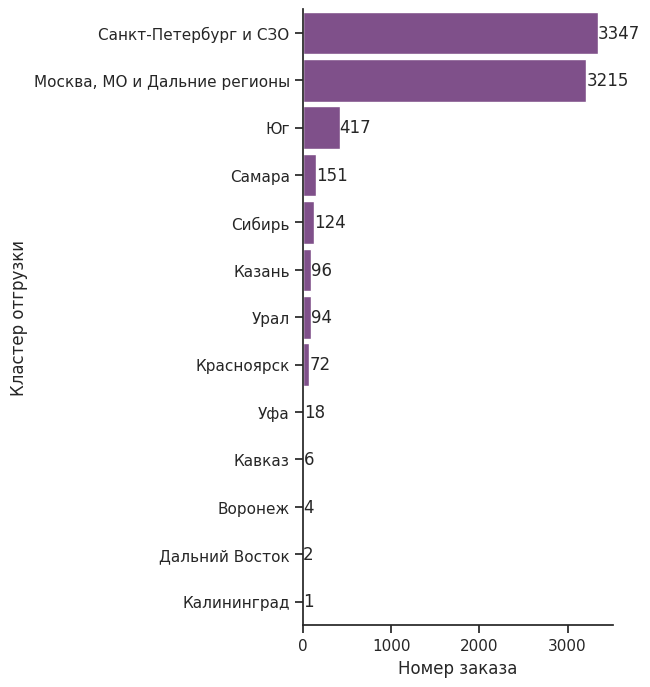

In [7]:
# Всего продаж по кластерам
f, ax = plt.subplots(figsize=(4, 8))
data = (
    df
    .groupby('Кластер отгрузки')
    ['Номер заказа']
    .count()
    .sort_values(ascending=False)
)
sns.barplot(data, orient='h', width=0.9)
ax.bar_label(ax.containers[0])
sns.despine()

In [8]:
# daily sales data
# Ежедневные заказы
# Является набором данных для модели
target_clusters = ['Санкт-Петербург и СЗО', 'Москва, МО и Дальние регионы']
rename_dict = {
    'Принят в обработку': 'date',
}

df_daily_sales = (
    df
    # Можно раскомментировать, чтобы смотреть лишь на данные из указанных кластеров
    # .loc[lambda x: x['Кластер отгрузки'].isin(target_clusters)]
    .rename(columns=rename_dict)
    .groupby(
        pd.Grouper(key='date', freq='D')
    )
    .agg(count = ('Номер заказа', 'nunique'))
)
df_daily_sales

,count
date,
2024-02-02,3
2024-02-03,7
2024-02-04,6
2024-02-05,4
2024-02-06,8
...,...
2025-09-21,8
2025-09-22,7
2025-09-23,7


 # Анализ

 ## Обзор данных
 ### Динамика заказов на полном отрезке данных и 7ми дневное сглаживание средним

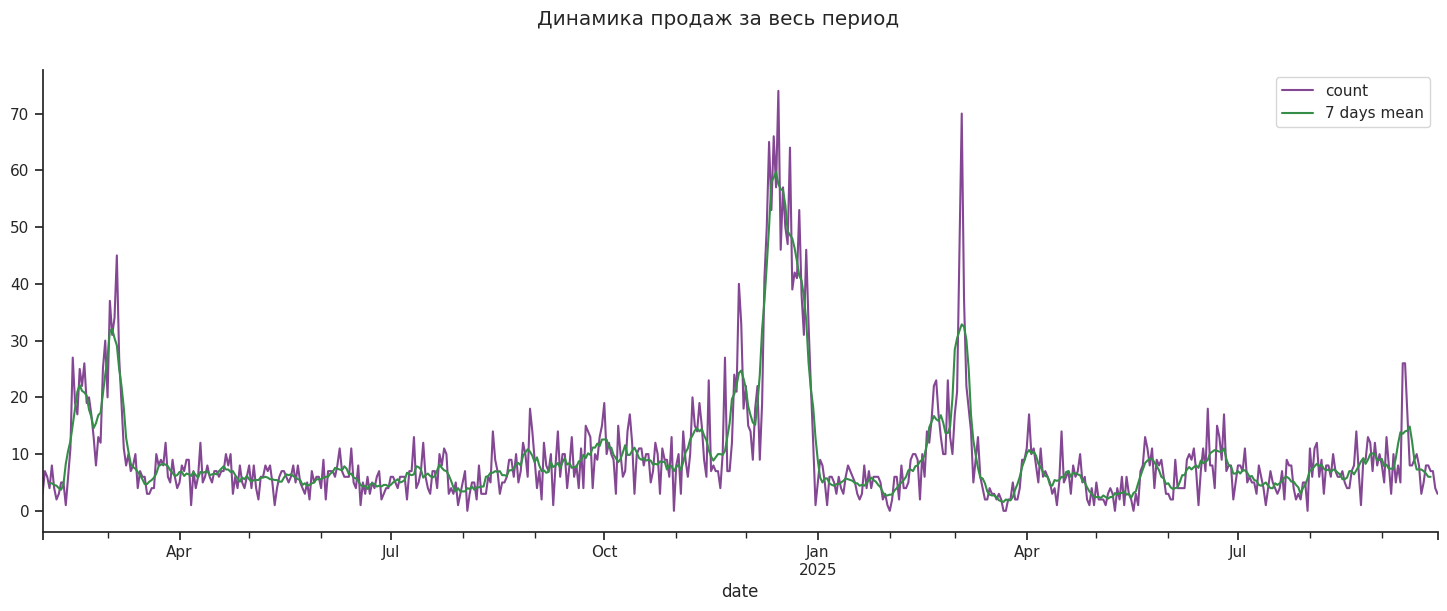

In [9]:
d = 7
f, ax = plt.subplots(figsize=(18, 6))
(
    df_daily_sales
    .plot(ax=ax)
)
(
    df_daily_sales
    .rolling(d, center=True)
    .mean()
    .rename(columns={'count': f'{d} days mean'})
    .plot(ax=ax, color=palette[-1])
)
f.suptitle('Динамика продаж за весь период')
sns.despine()

 ### Объем продаж

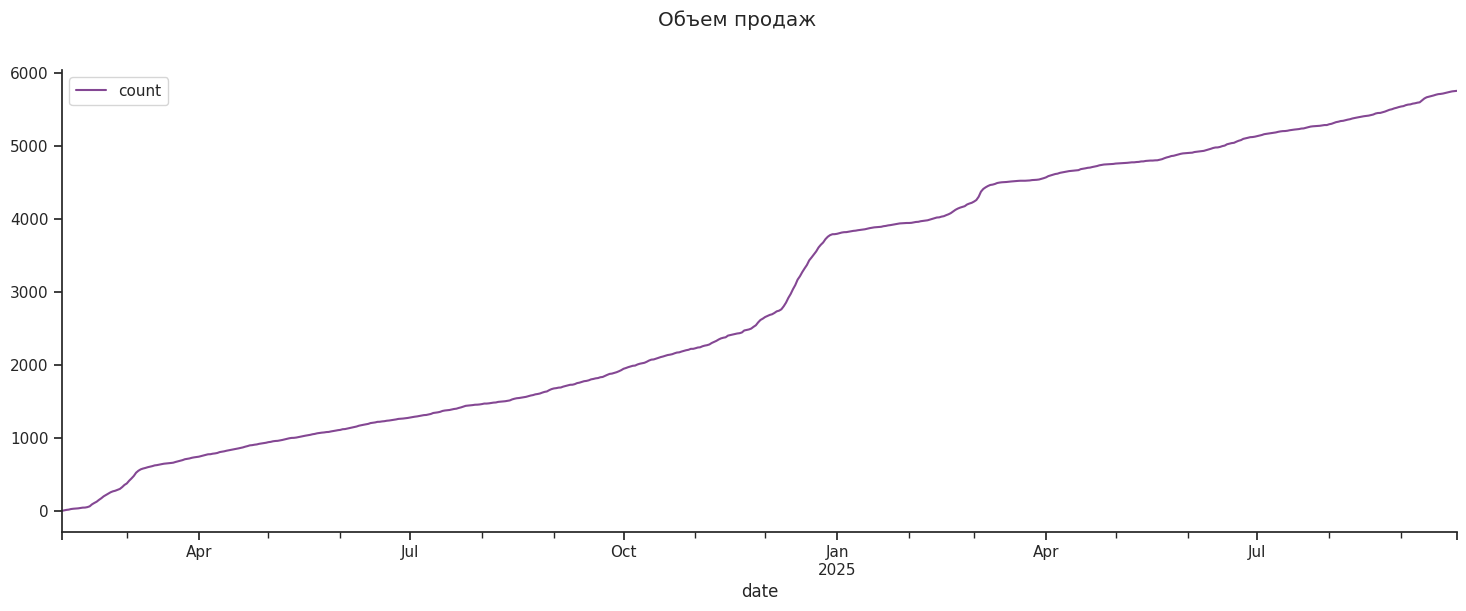

In [10]:
# Объем продаж
f, ax = plt.subplots(figsize=(18, 6))
(
    df_daily_sales
    .cumsum()
    .plot(ax=ax)
)
f.suptitle('Объем продаж')
sns.despine()

In [11]:
(
    df_daily_sales
    .sort_values('count', ascending=False)
)

,count
date,
2024-12-15,74
2025-03-04,70
2024-12-13,66
2024-12-11,65
2024-12-20,64
...,...
2025-05-09,0
2025-03-22,0
2025-02-01,0


 ### Разница с лагом 1

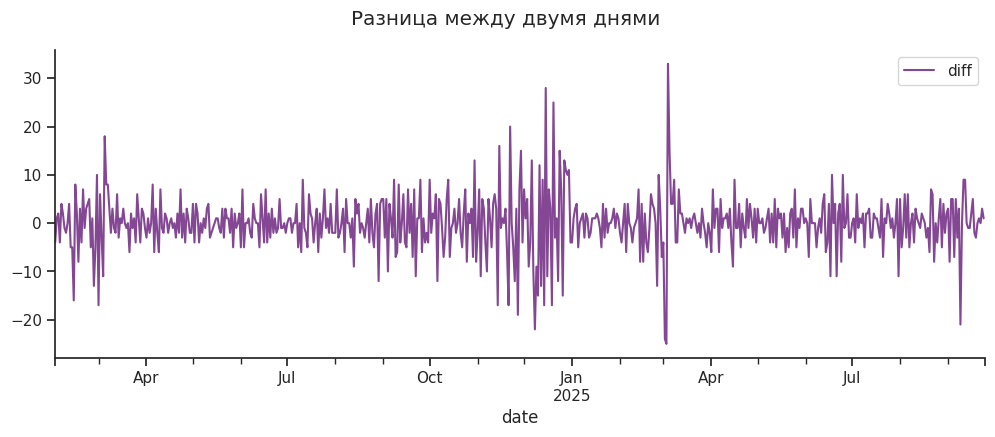

In [12]:
# 1 day lag diff
f, ax = plt.subplots(figsize=(12, 4))
(
    df_daily_sales
    .assign(
        diff = lambda x: x['count'] - x['count'].shift(-1)
    )
    [['diff']]
    .plot(ax = ax)
)
f.suptitle('Разница между двумя днями')
sns.despine()

 ### Распределение продаж

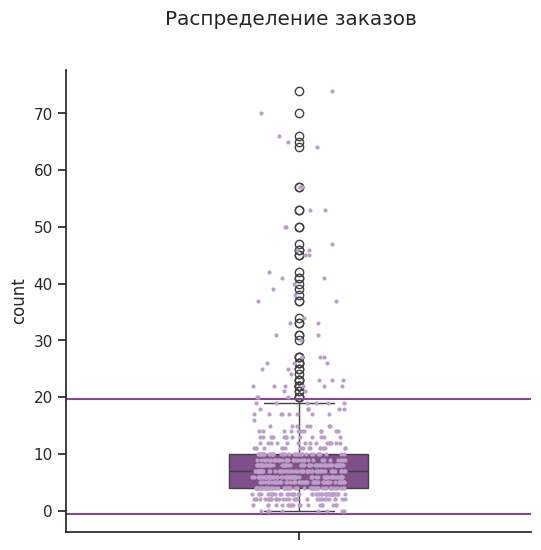

In [13]:
data = df_daily_sales['count']
f, ax = plt.subplots(figsize=(6,6))
f.suptitle('Распределение заказов')

sns.boxplot(
    data,
    width=0.3,
) 
sns.stripplot(
    data,
    size=3
)
ax.axhline(data[data < 800].mean() - data[data < 800].std())
ax.axhline(data[data < 800].mean() + data[data < 800].std())
sns.despine()

In [14]:
# peak z score
data.max() / data.std()

np.float64(7.2887347089421795)

 ## Месячная сезонность

 На графике значения за каждый из месяцев. Для некоторых данные отсутствуют. Красные линии - среднее среди всех
 наблюдений за этот месяц, черные - динамика между аналогичными периодами.\
 Разница в высоте линий говорит о наличии сезонности в продажах

(96.55, 500.0)

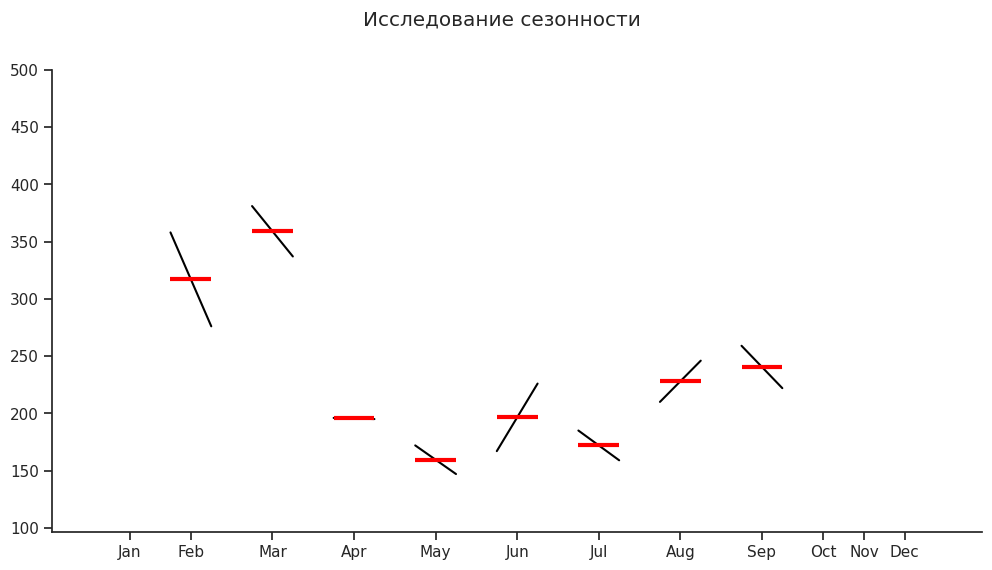

In [15]:
f, ax = plt.subplots(figsize=(12,6))
month_plot(df_daily_sales.resample('ME').sum(), ax=ax)
sns.despine()
plt.suptitle('Исследование сезонности')
ax.set_ylim(top=500)

 ## Возможность предсказаний в дневном измерении

 График показывает отношение между временным рядом и его смещенной в прошлое версией, чтобы продемонстрировать корреляцию
 между прошлыми и текущими значениями\
 Конкретно здесь можно увидеть, что в смещениях до 14 дней содержится информация о текущих значениях\
 Парабола в центре, своего рода доверительный интервал 95%. Значения внутри не имеют статистической значимости\
 Сдвиги после 20-го попадают в интервал и не представляют интереса

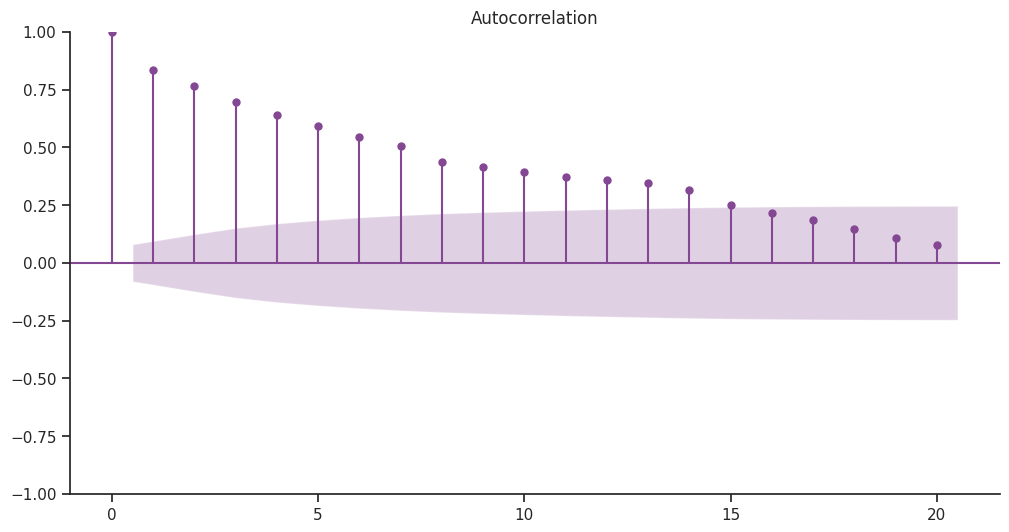

In [16]:
data = df_daily_sales
f, ax = plt.subplots(figsize=(12,6))
plot_acf(data, lags=20, ax=ax)
sns.despine()

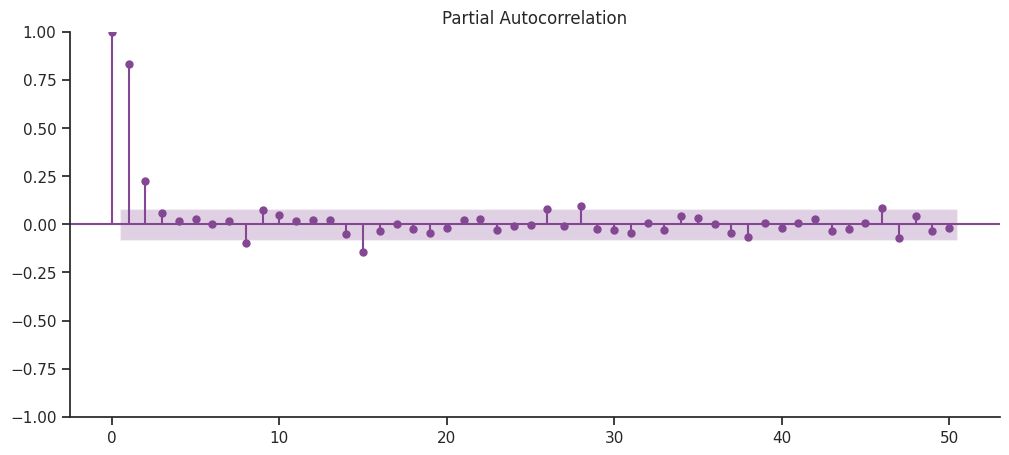

In [17]:
f, ax = plt.subplots(figsize=(12,5))
plot_pacf(data, lags=50, ax=ax)
sns.despine()

 ## Возможность предсказаний в месячном измеренении
 Невозможно

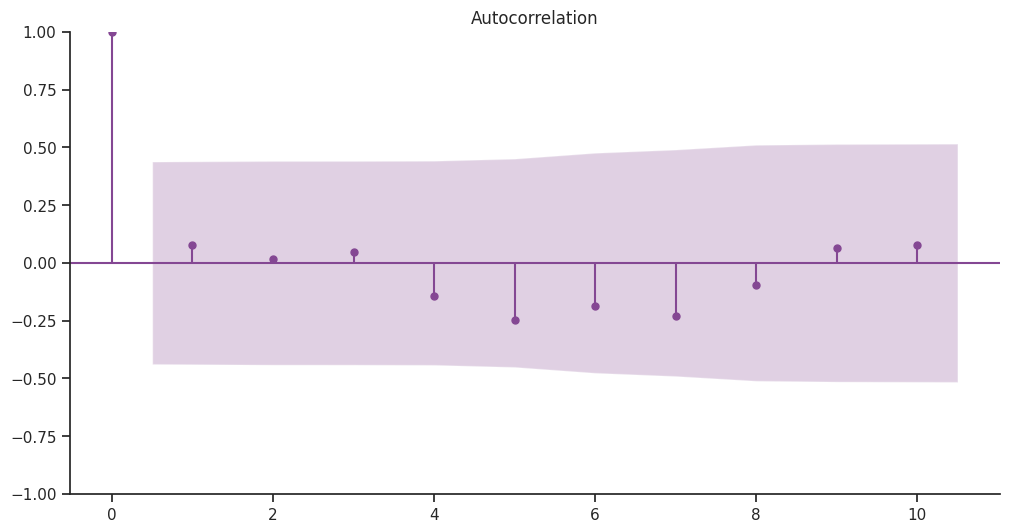

In [18]:
data = df_daily_sales.resample('ME').sum()
f, ax = plt.subplots(figsize=(12,6))
plot_acf(data, lags=10, ax=ax)
sns.despine()

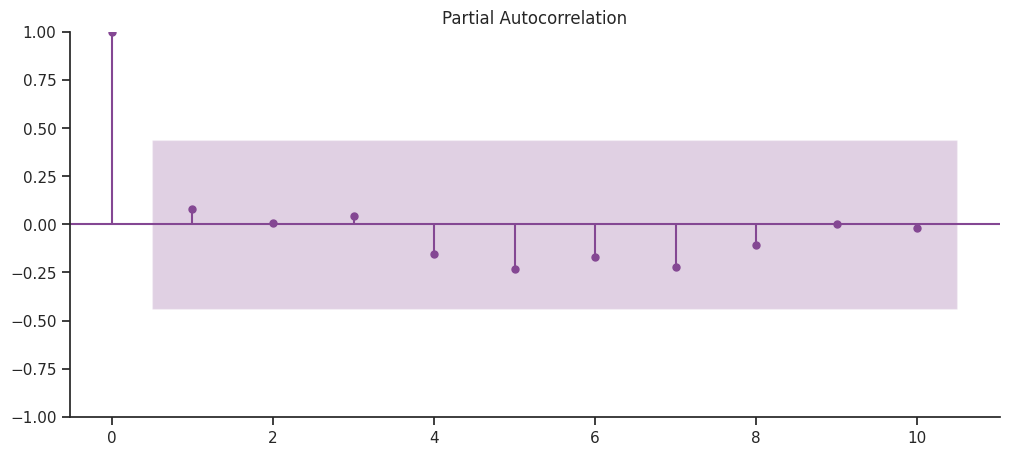

In [19]:
f, ax = plt.subplots(figsize=(12,5))
plot_pacf(data, lags=10, ax=ax)
sns.despine()

In [20]:
# Сезонная декомпозиция. Мало данных
# dcmps= seasonal_decompose(df_daily_sales.resample('').sum())
# fig = dcmps.plot()
# sns.despine()
# fig.set_size_inches((16,16))
# fig.axes[3].clear()
# fig.axes[3].bar(height=dcmps.resid, x=fig.axes[0].lines[0].get_xdata(), )
# fig.axes[3].set_ylabel('Residual')
# fig.axes[3].tick_params('x', bottom=False)

 ## Предсказания на основе средних продаж

 Считаем средние продажи за последние n дней, включая упущенные, и делаем предсказание по формуле\
 поставка = среднее количество продаж за n дней × количество дней в следующем месяце - остатки если есть\
 Таким образом для предсказания мы всегда используем средние продажи, предыдущего периода\
 Первый период пропускается\
 \
 **Метрики** для оценивания:\
 **MAE**(mean average error) - средняя разница между истинным значением и предсказанием. Меньше - лучше. Показывает насколько близко предсказание к истинному значению\
 **SUM**(summation) - сумма всех разниц между истинным значением и предсказанием. Меньше - лучше\
 **RMSE**(root mean square error) - корень суммы квадратов всех разниц между истинным значением и предсказанием. Меньше - лучше. Чем меньше, тем плотнее предсказание "прилегает" к истинному значению в абсолютных числах

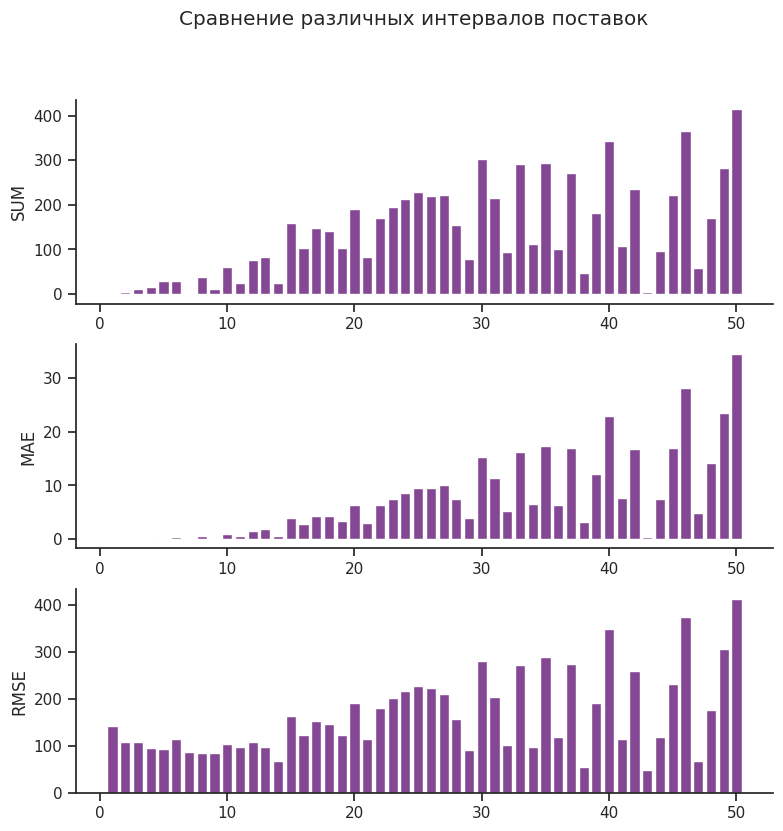

In [21]:
res = []
for period in range(1, 51):
    data = (
        df_daily_sales
        .assign(
            # for n days
            # shift makes left end of rolling non inclusive
            turnover_rate=lambda x:
            (
                x
                ['count']
                .rolling(period)
                .mean()
            ).shift()
        )
        .groupby(
            pd.Grouper(freq=f'{period}d')
        )
        .agg({
            'count': 'sum',
            'turnover_rate': 'last'
        })
        .assign(
            pred=lambda x: round(x['turnover_rate'] * period),
            diff=lambda x: (x['pred'] - x['count']),
        )
        [['diff']]
    )
    res.append((
        period, 
        float(round(data.mean().values[0], 2)), 
        round(data.sum().values[0]),
        float(round(np.sqrt((data**2).sum().values[0])))
    ))
x, maes, sums, rmses = zip(*res)
f, ax = plt.subplots(figsize=(9,9), nrows=3)
ax[0].bar(x, sums)
ax[0].set_ylabel('SUM')
ax[1].bar(x, maes)
# mean average error
# Средняя ошибка
ax[1].set_ylabel('MAE')
# root mean square error
# Насколько абсолютно близко подходит к данным
ax[2].bar(x, rmses)
ax[2].set_ylabel('RMSE')
f.suptitle('Сравнение различных интервалов поставок')
sns.despine()

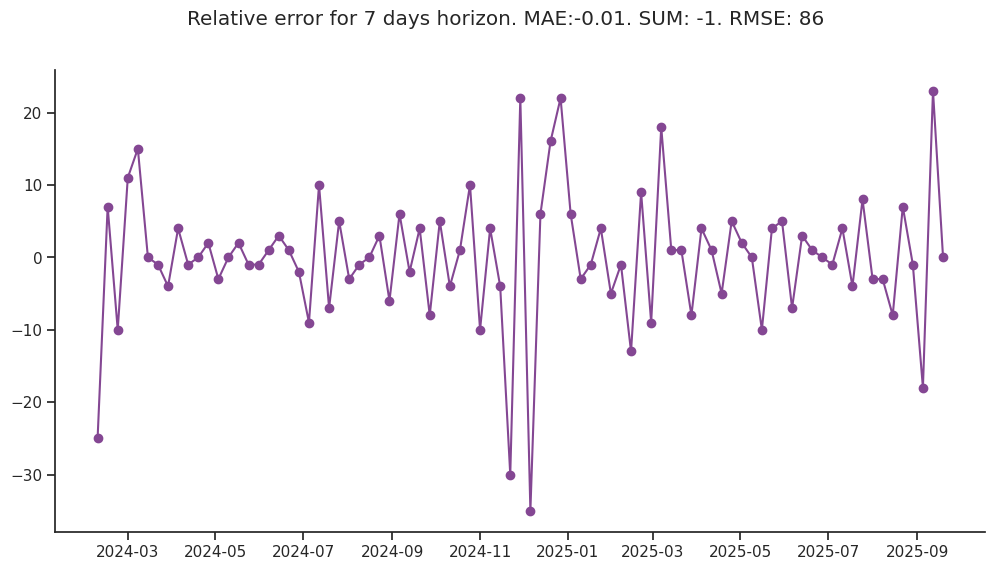

In [22]:
# Поставка каждые 7 дней
period = 7
storage_payment_per_day = 1.5
data = (
    df_daily_sales
    .assign(
        turnover_rate=lambda x:
        (
            x
            ['count']
            .rolling(period)
            .mean()
        ).shift()
    )
    .groupby(
        pd.Grouper(freq=f'{period}d')
    )
    .agg({
        'count': 'sum',
        'turnover_rate': 'last'
    })
    .assign(
        pred=lambda x: round(x['turnover_rate'] * period),
        diff=lambda x: (x['pred'] - x['count']),
    )
)
mae = round(data[['diff']].mean().values[0], 2)
tsum = round(data[['diff']].sum().values[0])
rmse = round(np.sqrt((data[['diff']]**2).sum().values[0]))
f, ax = plt.subplots(figsize=(12,6))
plt.plot(data[['diff']], marker='o')
plt.suptitle(f'Relative error for {period} days horizon. MAE:{mae}. SUM: {tsum}. RMSE: {rmse}')
sns.despine()

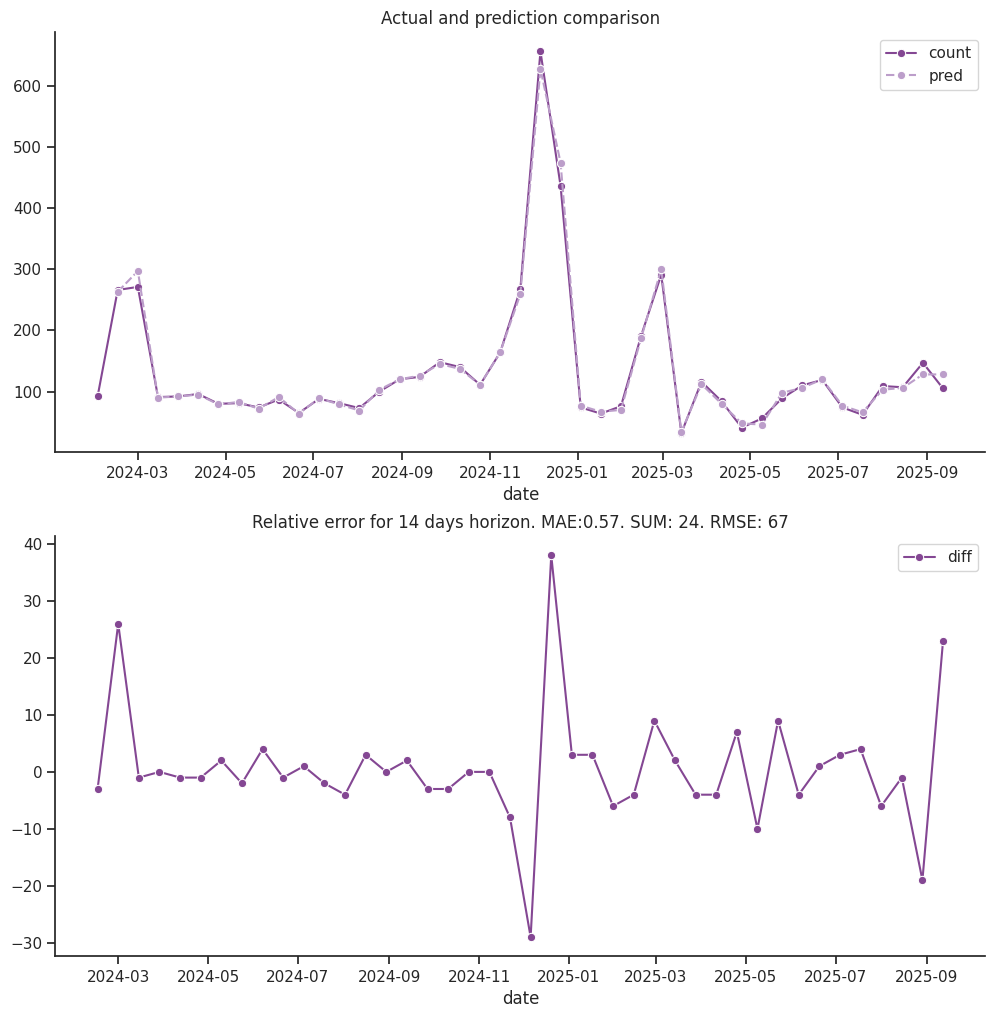

In [23]:
# Поставка каждые 14 дней
period = 14
storage_payment_per_day = 1.5
data = (
    df_daily_sales
    .assign(
        # for n days
        # shift makes left end of rolling non inclusive
        turnover_rate=lambda x:
        (
            x
            ['count']
            .rolling(period)
            .mean()
        ).shift()
    )
    .groupby(
        pd.Grouper(freq=f'{period}d')
    )
    .agg({
        'count': 'sum',
        'turnover_rate': 'last'
    })
    .assign(
        pred=lambda x: round(x['turnover_rate'] * period),
        diff=lambda x: (x['pred'] - x['count']),
        pay=lambda x: x['diff'] * period
    )
)
mae = round(data[['diff']].mean().values[0], 2)
tsum = round(data[['diff']].sum().values[0])
rmse = round(np.sqrt((data[['diff']]**2).sum().values[0]))

f, ax = plt.subplots(figsize=(12,12), nrows=2)
sns.lineplot(data[['diff']], marker='o', ax=ax[1])
sns.lineplot(data[['count', 'pred']], marker='o', ax=ax[0])
ax[1].set_title(f'Relative error for {period} days horizon. MAE:{mae}. SUM: {tsum}. RMSE: {rmse}')
ax[0].set_title('Actual and prediction comparison')
sns.despine()

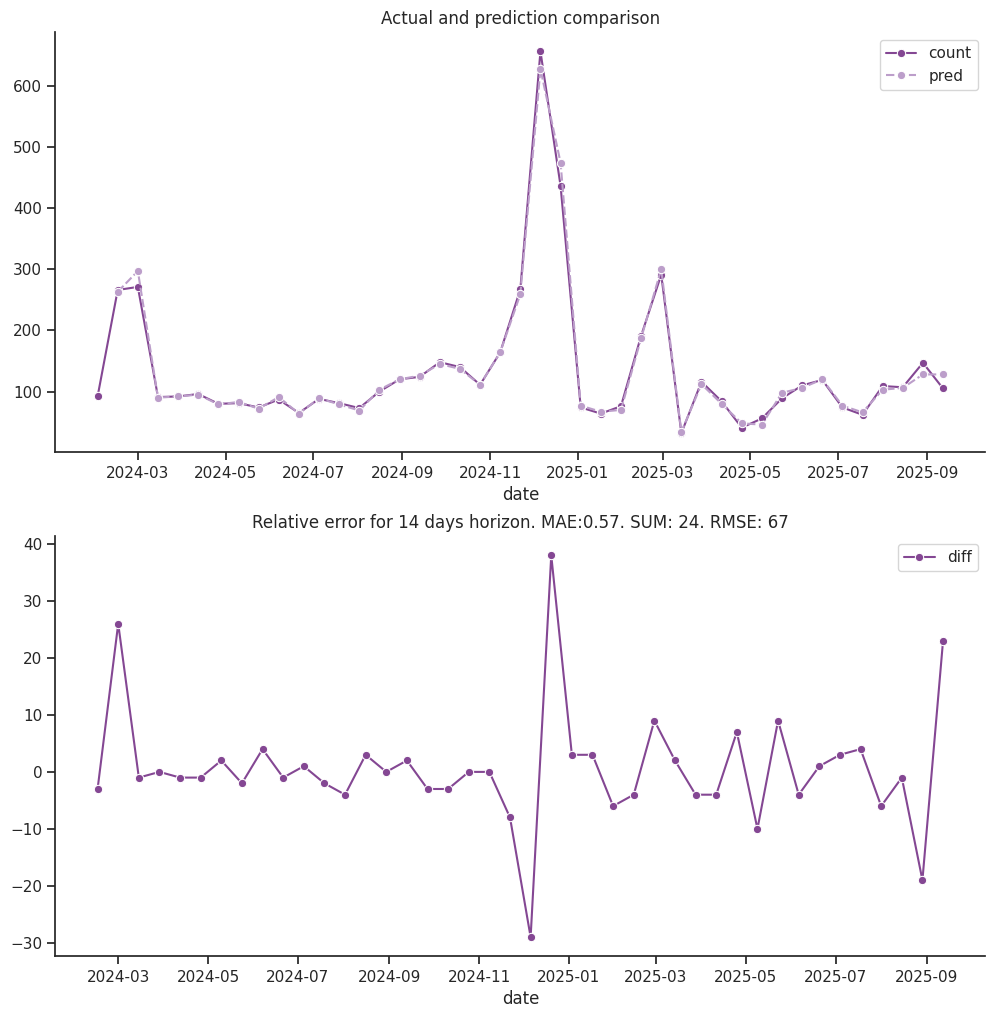

In [24]:
period = 14
storage_payment_per_day = 1.5
data = (
    df_daily_sales
    .assign(
        # for n days
        # shift makes left end of rolling non inclusive
        turnover_rate=lambda x:
        (
            x
            ['count']
            .rolling(period)
            .mean()
        ).shift()
    )
    .groupby(
        pd.Grouper(freq=f'{period}d')
    )
    .agg({
        'count': 'sum',
        'turnover_rate': 'last'
    })
    .assign(
        pred=lambda x: round(x['turnover_rate'] * period),
        diff=lambda x: (x['pred'] - x['count']),
        pay=lambda x: x['diff'] * period
    )
)

f, ax = plt.subplots(figsize=(12,12), nrows=2)
sns.lineplot(data[['diff']], marker='o', ax=ax[1])
sns.lineplot(data[['count', 'pred']], marker='o', ax=ax[0])
ax[1].set_title(f'Relative error for {period} days horizon. MAE:{mae}. SUM: {tsum}. RMSE: {rmse}')
ax[0].set_title('Actual and prediction comparison')
sns.despine()

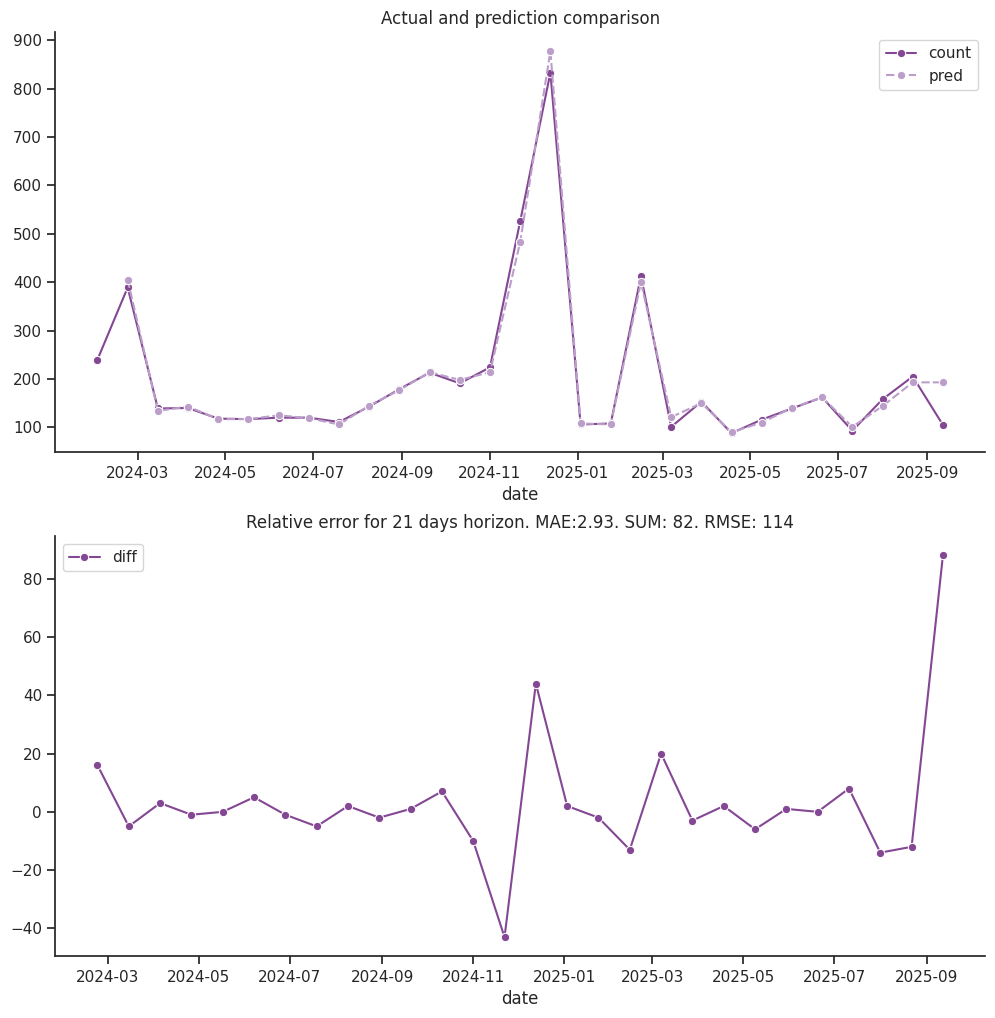

In [25]:
# Поставка каждые 21 дней
period = 21
data = (
    df_daily_sales
    .assign(
        # for n days
        # shift makes left end of rolling non inclusive
        turnover_rate=lambda x:
        (
            x
            ['count']
            .rolling(period)
            .mean()
        ).shift()
    )
    .groupby(
        pd.Grouper(freq=f'{period}d')
    )
    .agg({
        'count': 'sum', 
        'turnover_rate': 'last'
    })
    .assign(
        pred=lambda x: round(x['turnover_rate'] * period),
        diff=lambda x: (x['pred'] - x['count']),
    )
)
mae = round(data[['diff']].mean().values[0], 2)
tsum = round(data[['diff']].sum().values[0])
rmse = round(np.sqrt((data[['diff']]**2).sum().values[0]))

f, ax = plt.subplots(figsize=(12,12), nrows=2)
sns.lineplot(data[['diff']], marker='o', ax=ax[1])
sns.lineplot(data[['count', 'pred']], marker='o', ax=ax[0])
ax[1].set_title(f'Relative error for {period} days horizon. MAE:{mae}. SUM: {tsum}. RMSE: {rmse}')
ax[0].set_title('Actual and prediction comparison')
sns.despine()

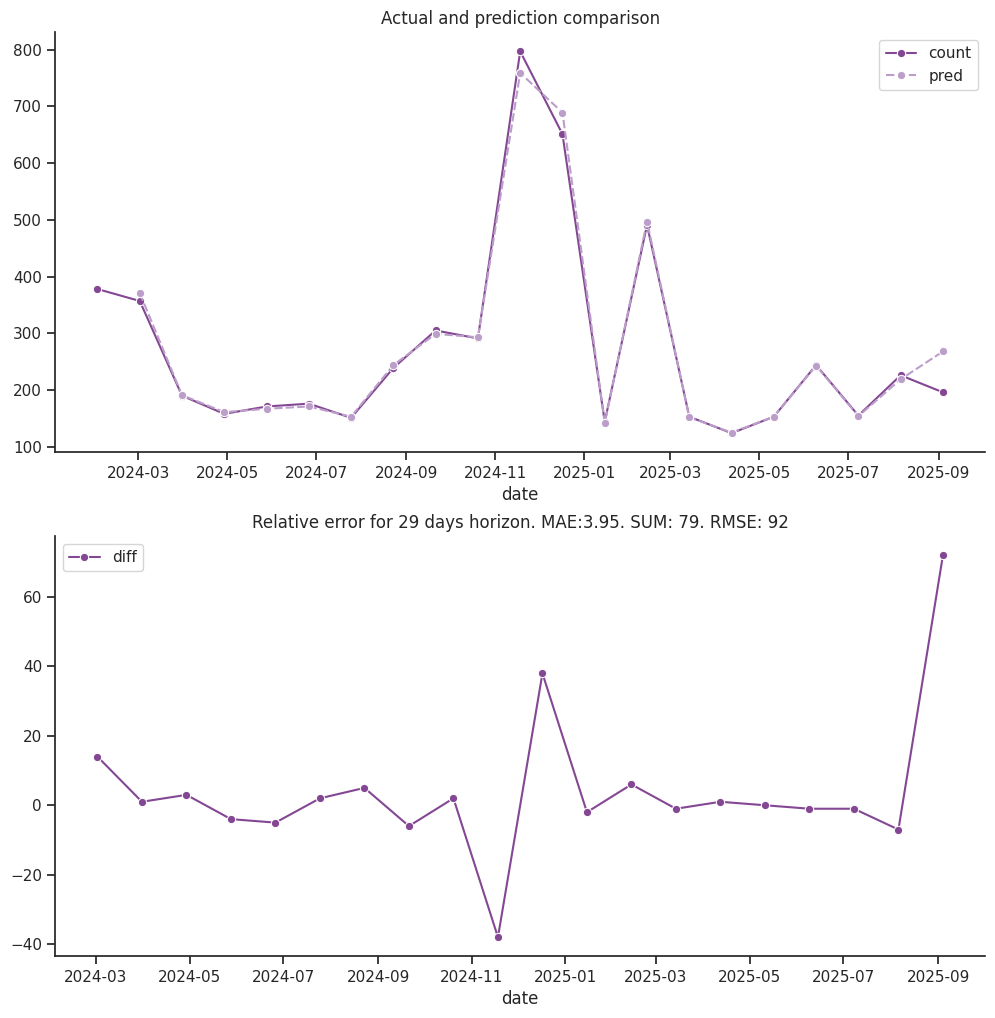

In [26]:
# Поставка каждые 29 дней
period = 29
data = (
    df_daily_sales
    .assign(
        # for n days
        # shift makes left end of rolling non inclusive
        turnover_rate=lambda x:
        (
            x
            ['count']
            .rolling(period)
            .mean()
        ).shift()
    )
    .groupby(
        pd.Grouper(freq=f'{period}d')
    )
    .agg({
        'count': 'sum', 
        'turnover_rate': 'last'
    })
    .assign(
        pred=lambda x: round(x['turnover_rate'] * period),
        diff=lambda x: (x['pred'] - x['count']),
    )
)
mae = round(data[['diff']].mean().values[0], 2)
tsum = round(data[['diff']].sum().values[0])
rmse = round(np.sqrt((data[['diff']]**2).sum().values[0]))

f, ax = plt.subplots(figsize=(12,12), nrows=2)
sns.lineplot(data[['diff']], marker='o', ax=ax[1])
sns.lineplot(data[['count', 'pred']], marker='o', ax=ax[0])
ax[1].set_title(f'Relative error for {period} days horizon. MAE:{mae}. SUM: {tsum}. RMSE: {rmse}')
ax[0].set_title('Actual and prediction comparison')
sns.despine()

 # Результаты
 ## Модель
 * Является понятной и интепретируемой
 * Не требует сложных алгоритмов
 * Не требует большого количества данных
 * Демонстрируемые результаты проявляются лишь при долгосрочном использовании стратегии
 * Модель не учитывает сезонность и долговременные тренды
 * Модель может быть применена для отдельных артикулов
 * Сравнительно короткий горизонт прогнозирования
 * При более частых поставках долгосрочные потери меньше, и лучше описываются кратковременные тренды
 * Метрики этой модели могут быть использованы для оценки более сложных
 * Полученная модель может служить базой для оценки более сложных моделей
 * В целом у данных есть потенциал для обучения более сложных моделей при большем наборе данных

 ## Данные
 * Наблюдается сезонность
 * Болшинство продаж приходится на кластеры СПб + Москва. При этом между собой кластеры примерно равны
 * Есть "горячие" периоды: праздники(8 марта, 23 февраля, Новый Год)